WD 0 - Epoch 1: Loss 0.5124
WD 0 - Epoch 2: Loss 0.3728
WD 0 - Epoch 3: Loss 0.3350
WD 0 - Epoch 4: Loss 0.3081
WD 0 - Epoch 5: Loss 0.2911
WD 0.001 - Epoch 1: Loss 0.5187
WD 0.001 - Epoch 2: Loss 0.4000
WD 0.001 - Epoch 3: Loss 0.3736
WD 0.001 - Epoch 4: Loss 0.3533
WD 0.001 - Epoch 5: Loss 0.3404
WD 0.1 - Epoch 1: Loss 0.8805
WD 0.1 - Epoch 2: Loss 0.8121
WD 0.1 - Epoch 3: Loss 0.8082
WD 0.1 - Epoch 4: Loss 0.8016
WD 0.1 - Epoch 5: Loss 0.7995


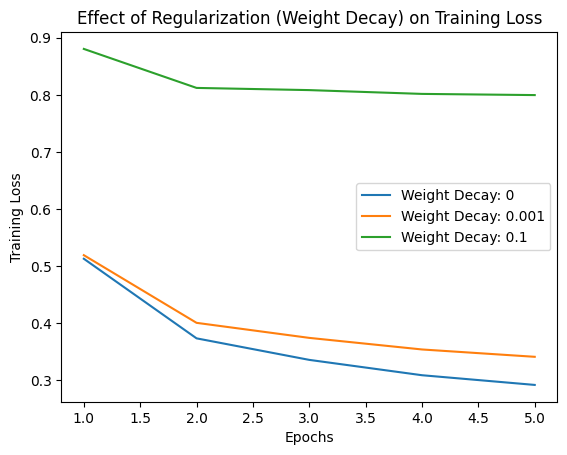

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# --- 1. DATA PREPROCESSING ---
# Simple scaling: Convert images to numbers (0-1) and normalize them.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset and split 50k for training, 10k for internal validation
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_subset, val_subset = random_split(full_dataset, [50000, 10000])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

# --- 2. MODEL DEFINITION ---
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten()
        # A simple 3-layer architecture: 784 input -> 256 hidden -> 128 hidden -> 10 output
        self.layers = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

# --- 3. THE EXPERIMENT FUNCTION ---
def run_experiment(weight_decay_val):
    model = FashionClassifier()
    criterion = nn.CrossEntropyLoss()
    # Research Line: Changing only the weight_decay parameter
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay_val)

    epochs = 5
    epoch_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            # The 5-Step Learning Process:
            optimizer.zero_grad()           # 1. Clear old slopes
            outputs = model(images)         # 2. Predict
            loss = criterion(outputs, labels) # 3. Calculate error
            loss.backward()                 # 4. Find error direction
            optimizer.step()                # 5. Update weights (Apply Weight Decay)

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"WD {weight_decay_val} - Epoch {epoch+1}: Loss {avg_loss:.4f}")

    return epoch_losses

# --- 4. EXECUTION & VISUALIZATION ---
# We test three specific settings: No regularization, Small, and Large
wd_settings = [0, 0.001, 0.1]
results = {}

for wd in wd_settings:
    results[wd] = run_experiment(wd)

# Plotting the results for the report
plt.figure()
for wd, losses in results.items():
    plt.plot(range(1, 6), losses, label=f'Weight Decay: {wd}')

plt.title('Effect of Regularization (Weight Decay) on Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(False)
plt.show()